<a href="https://colab.research.google.com/github/nick21aka/API.PY/blob/main/EP3_Transformer_Traduccion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Parcial N°3 — Entregable 2: Modelo Transformer
## Deep Learning (DLY0100) — Traducción Automática Inglés → Español

**Integrantes:** _(completar nombres)_
**Fecha:** Julio 2026

---

## 1. Introducción

### Descripción del problema

Se implementa una arquitectura **Transformer** (encoder-decoder con *multi-head attention*) construida desde
cero, aplicada a la tarea de **traducción automática de oraciones cortas del inglés al español**.

Se usa el dataset `spa-eng` (pares de oraciones inglés-español), alojado directamente por TensorFlow, por lo que
se descarga automáticamente al ejecutar la celda de carga de datos (no requiere configuración adicional en
Colab).

### Objetivos

1. Implementar una arquitectura Transformer básica (encoder, decoder, multi-head attention).
2. Explicar el rol de cada componente (embeddings + codificación posicional, autoatención, feed-forward).
3. Aplicar el modelo a la tarea de traducción automática.
4. Evaluar el desempeño con la métrica **BLEU**.
5. Analizar críticamente ejemplos de traducciones (aciertos y errores).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import string
import random

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)


TensorFlow version: 2.20.0


In [2]:
# NLTK para calcular BLEU
import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smoothie = SmoothingFunction().method4


## 2. Carga y preprocesamiento de datos

El dataset contiene pares `(oración en inglés, oración en español)` separados por tabulador. Se limpia el texto
(minúsculas, se quita puntuación no relevante) y se agregan los tokens especiales `[start]` y `[end]` a las
oraciones en español, que el decoder necesita para saber cuándo comenzar y terminar de generar la traducción.


In [5]:
import os

text_file_dir = keras.utils.get_file(
    fname="spa-eng.zip",
    origin="http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip",
    extract=True,
)
# The 'spa.txt' file is located inside a 'spa-eng' subdirectory within the extracted folder.
text_file = os.path.join(text_file_dir, "spa-eng", "spa.txt")

with open(text_file, encoding="utf-8") as f:
    lines = f.read().split("\n")[:-1]

text_pairs = []
for line in lines:
    eng, spa = line.split("\t")
    spa = "[start] " + spa + " [end]"
    text_pairs.append((eng, spa))

print(f"Total de pares: {len(text_pairs)}")
for pair in random.sample(text_pairs, 3):
    print(pair)

Total de pares: 118964
('There is no doubt about his ability.', '[start] No hay ninguna duda sobre su habilidad. [end]')
('They were amazing.', '[start] Fueron maravillosos. [end]')
("That'll last.", '[start] Durará. [end]')


In [6]:
# Split train / val / test
random.shuffle(text_pairs)
n_val = int(0.15 * len(text_pairs))
n_train = len(text_pairs) - 2 * n_val

train_pairs = text_pairs[:n_train]
val_pairs = text_pairs[n_train:n_train + n_val]
test_pairs = text_pairs[n_train + n_val:]

print(f"{len(train_pairs)} pares de entrenamiento")
print(f"{len(val_pairs)} pares de validación")
print(f"{len(test_pairs)} pares de prueba")


83276 pares de entrenamiento
17844 pares de validación
17844 pares de prueba


In [7]:
strip_chars = string.punctuation.replace("[", "").replace("]", "")

def custom_standardization(input_string):
    lowercase = tf.strings.lower(input_string)
    return tf.strings.regex_replace(lowercase, f"[{re.escape(strip_chars)}]", "")

VOCAB_SIZE = 15000
SEQ_LENGTH = 20

eng_vectorization = layers.TextVectorization(
    max_tokens=VOCAB_SIZE, output_mode="int", output_sequence_length=SEQ_LENGTH
)
spa_vectorization = layers.TextVectorization(
    max_tokens=VOCAB_SIZE, output_mode="int", output_sequence_length=SEQ_LENGTH + 1,
    standardize=custom_standardization,
)

train_eng_texts = [pair[0] for pair in train_pairs]
train_spa_texts = [pair[1] for pair in train_pairs]
eng_vectorization.adapt(train_eng_texts)
spa_vectorization.adapt(train_spa_texts)

print("Vocabulario inglés:", len(eng_vectorization.get_vocabulary()))
print("Vocabulario español:", len(spa_vectorization.get_vocabulary()))


Vocabulario inglés: 12062
Vocabulario español: 15000


In [8]:
def format_dataset(eng, spa):
    eng = eng_vectorization(eng)
    spa = spa_vectorization(spa)
    return ({"encoder_inputs": eng, "decoder_inputs": spa[:, :-1]}, spa[:, 1:])

def make_dataset(pairs, batch_size=64):
    eng_texts, spa_texts = zip(*pairs)
    eng_texts, spa_texts = list(eng_texts), list(spa_texts)
    dataset = tf.data.Dataset.from_tensor_slices((eng_texts, spa_texts))
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(format_dataset)
    return dataset.shuffle(2048).prefetch(tf.data.AUTOTUNE).cache()

BATCH_SIZE = 64
train_ds = make_dataset(train_pairs, BATCH_SIZE)
val_ds = make_dataset(val_pairs, BATCH_SIZE)

for inputs, targets in train_ds.take(1):
    print("encoder_inputs shape:", inputs["encoder_inputs"].shape)
    print("decoder_inputs shape:", inputs["decoder_inputs"].shape)
    print("targets shape:", targets.shape)


encoder_inputs shape: (64, 20)
decoder_inputs shape: (64, 20)
targets shape: (64, 20)


## 3. Definición del modelo: arquitectura Transformer

### Componentes clave

- **Positional Embedding**: como el Transformer no procesa la secuencia en orden (a diferencia de una RNN),
  necesita que se le inyecte explícitamente la posición de cada palabra, sumando un *embedding posicional* al
  embedding del token.
- **Multi-Head Attention (autoatención)**: permite que cada palabra "mire" a todas las demás palabras de la
  secuencia y pondere cuáles son relevantes para representarla, capturando relaciones de largo alcance sin la
  limitación secuencial de una RNN. Usar *múltiples cabezas* permite capturar distintos tipos de relaciones en
  paralelo (ej. una cabeza puede enfocarse en relaciones sintácticas y otra en semánticas).
- **Encoder**: procesa la oración en inglés completa y produce una representación contextualizada de cada token.
- **Decoder**: genera la oración en español palabra por palabra, usando (a) autoatención enmascarada sobre lo ya
  generado, y (b) atención cruzada (*cross-attention*) sobre la salida del encoder, para "consultar" la oración
  original en cada paso.
- **Feed-Forward + Add & Norm**: cada bloque de atención se combina con una red feed-forward y conexiones
  residuales + normalización, lo que facilita el entrenamiento de arquitecturas profundas.


In [15]:
class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.dense_proj = keras.Sequential([
            layers.Dense(dense_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()
        self.supports_masking = True # Added for mask propagation

    def call(self, inputs, mask=None):
        tf.print("Encoder inputs shape:", tf.shape(inputs), summarize=-1)
        if mask is not None:
            tf.print("Encoder mask shape (before processing):", tf.shape(mask), summarize=-1)
            # mask is boolean [batch_size, sequence_length] (True for valid tokens)
            # Create an attention mask for self-attention of shape [batch_size, sequence_length, sequence_length]
            # where True means 'attend' and False means 'mask out'.
            query_mask = tf.cast(mask, dtype=tf.bool) # [B, S]
            key_mask = tf.cast(mask, dtype=tf.bool)   # [B, S]
            attention_mask = tf.expand_dims(query_mask, axis=-1) & tf.expand_dims(key_mask, axis=-2) # [B, S, S]
            tf.print("Encoder attention_mask shape (after processing):", tf.shape(attention_mask), summarize=-1)
        else:
            attention_mask = None
            tf.print("Encoder mask is None.")
        attention_output = self.attention(query=inputs, value=inputs, key=inputs, attention_mask=attention_mask)
        proj_input = self.layernorm_1(inputs + attention_output)
        proj_output = self.dense_proj(proj_input)
        return self.layernorm_2(proj_input + proj_output)


class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.position_embeddings = layers.Embedding(input_dim=sequence_length, output_dim=embed_dim)
        self.sequence_length = sequence_length
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim

    def call(self, inputs):
        length = tf.shape(inputs)[-1]
        positions = tf.range(start=0, limit=length, delta=1)
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions

    def compute_mask(self, inputs, mask=None):
        return keras.ops.not_equal(inputs, 0)


class TransformerDecoder(layers.Layer):
    def __init__(self, embed_dim, latent_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.latent_dim = latent_dim
        self.num_heads = num_heads
        self.attention_1 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.attention_2 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.dense_proj = keras.Sequential([
            layers.Dense(latent_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()
        self.layernorm_3 = layers.LayerNormalization()
        self.supports_masking = True

    def call(self, inputs, encoder_outputs, mask=None):
        causal_mask = self.get_causal_attention_mask(inputs)
        if mask is not None:
            padding_mask = tf.cast(mask[:, tf.newaxis, :], dtype="int32")
            padding_mask = tf.minimum(padding_mask, causal_mask)
        else:
            padding_mask = causal_mask

        attention_output_1 = self.attention_1(query=inputs, value=inputs, key=inputs, attention_mask=causal_mask)
        out_1 = self.layernorm_1(inputs + attention_output_1)

        attention_output_2 = self.attention_2(
            query=out_1, value=encoder_outputs, key=encoder_outputs, attention_mask=padding_mask
        )
        out_2 = self.layernorm_2(out_1 + attention_output_2)

        proj_output = self.dense_proj(out_2)
        return self.layernorm_3(out_2 + proj_output)

    def get_causal_attention_mask(self, inputs):
        input_shape = tf.shape(inputs)
        batch_size, sequence_length = input_shape[0], input_shape[1]
        i = tf.range(sequence_length)[:, tf.newaxis]
        j = tf.range(sequence_length)
        mask = tf.cast(i >= j, dtype="int32")
        mask = tf.reshape(mask, (1, sequence_length, sequence_length))
        mult = tf.concat([tf.expand_dims(batch_size, -1), tf.constant([1, 1], dtype=tf.int32)], axis=0)
        return tf.tile(mask, mult)

### Justificación de hiperparámetros

- `EMBED_DIM`: dimensión de los embeddings de token/posición — controla la capacidad del modelo para representar
  significado.
- `LATENT_DIM`: dimensión interna de la capa feed-forward dentro de cada bloque encoder/decoder.
- `NUM_HEADS`: número de cabezas de atención — más cabezas permiten capturar relaciones distintas en paralelo,
  a costa de más cómputo.

Se define una función `build_transformer` para poder instanciar fácilmente distintas configuraciones y
compararlas en la sección de ajuste de hiperparámetros.


In [10]:
def build_transformer(embed_dim=256, latent_dim=512, num_heads=8):
    encoder_inputs = keras.Input(shape=(None,), dtype="int64", name="encoder_inputs")
    x = PositionalEmbedding(SEQ_LENGTH, VOCAB_SIZE, embed_dim)(encoder_inputs)
    encoder_outputs = TransformerEncoder(embed_dim, latent_dim, num_heads)(x)

    decoder_inputs = keras.Input(shape=(None,), dtype="int64", name="decoder_inputs")
    encoded_seq_inputs = keras.Input(shape=(None, embed_dim), name="decoder_state_inputs")
    x = PositionalEmbedding(SEQ_LENGTH, VOCAB_SIZE, embed_dim)(decoder_inputs)
    x = TransformerDecoder(embed_dim, latent_dim, num_heads)(x, encoded_seq_inputs)
    x = layers.Dropout(0.5)(x)
    decoder_outputs = layers.Dense(VOCAB_SIZE, activation="softmax")(x)
    decoder = keras.Model([decoder_inputs, encoded_seq_inputs], decoder_outputs)

    decoder_outputs = decoder([decoder_inputs, encoder_outputs])
    transformer = keras.Model([encoder_inputs, decoder_inputs], decoder_outputs, name="transformer")
    return transformer

transformer = build_transformer(embed_dim=256, latent_dim=512, num_heads=8)
transformer.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'functional_2' (of type Functional) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 256) │  3,845,120 │ encoder_inputs[0… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encoder │ (None, None, 256) │  2,367,488 │ positional_embed… │
│ (TransformerEncode… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_2        │ (None, None,      │ 12,171,672 │ decoder_inputs[0… │
│ (Functional)        │ 15000)            │            │ transformer_enco… │
│                     │                   │            │ not_equal[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 18,384,280 (70.13 MB)

 Trainable params: 18,384,280 (70.13 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Entrenamiento y ajuste de hiperparámetros

Se entrena una configuración **base** y luego una configuración **alternativa** (variando `num_heads` y
`embed_dim`) para comparar su impacto en la calidad de las traducciones.

> ⚠️ Cada configuración puede tardar varios minutos por época en Colab con GPU. Se recomienda usar `EPOCHS` bajo
> (3-5) para efectos de la entrega y aumentarlo si se dispone de más tiempo/cómputo.


In [16]:
EPOCHS = 5

configs_transformer = [
    {"name": "Base (heads=8, embed=256)",    "embed_dim": 256, "latent_dim": 512, "num_heads": 8},
    {"name": "Alternativa (heads=4, embed=128)", "embed_dim": 128, "latent_dim": 256, "num_heads": 4},
]

transformer_results = {}

for cfg in configs_transformer:
    print(f"\n=== Entrenando: {cfg['name']} ===")
    model = build_transformer(cfg["embed_dim"], cfg["latent_dim"], cfg["num_heads"])
    model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"], jit_compile=False)
    history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=2)
    transformer_results[cfg["name"]] = {"model": model, "history": history, "config": cfg}


=== Entrenando: Base (heads=8, embed=256) ===
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'functional_14' (of type Functional) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Se han truncado las últimas 5000 líneas del flujo de salida.
Encoder mask shape (before processing): [64 20]
Encoder attention_mask shape (after processing): [64 20 20]
Encoder inputs shape: [64 20 256]
Encoder mask shape (before processing): [64 20]
Encoder attention_mask shape (after processing): [64 20 20]
Encoder inputs shape: [64 20 256]
Encoder mask shape (before processing): [64 20]
Encoder attention_mask shape (after processing): [64 20 20]
Encoder inputs shape: [64 20 256]
Encoder mask shape (before processing): [64 20]
Encoder attention_mask shape (after processing): [64 20 20]
Encoder inputs shape: [64 20 256]
Encoder mask shape (before processing): [64 20]
Encoder attention_mask shape (after processing): [64 20 20]
Encoder inputs shape: [64 20 256]
Encoder mask shape (before processing): [64 20]
Encoder attention_mask shape (after processing): [64 20 20]
Encoder inputs shape: [64 20 256]
Encoder mask shape (before processing): [64 20]
Encoder attention_mask shape (after pro

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'functional_17' (of type Functional) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Se han truncado las últimas 5000 líneas del flujo de salida.
Encoder mask shape (before processing): [64 20]
Encoder attention_mask shape (after processing): [64 20 20]
Encoder inputs shape: [64 20 128]
Encoder mask shape (before processing): [64 20]
Encoder attention_mask shape (after processing): [64 20 20]
Encoder inputs shape: [64 20 128]
Encoder mask shape (before processing): [64 20]
Encoder attention_mask shape (after processing): [64 20 20]
Encoder inputs shape: [64 20 128]
Encoder mask shape (before processing): [64 20]
Encoder attention_mask shape (after processing): [64 20 20]
Encoder inputs shape: [64 20 128]
Encoder mask shape (before processing): [64 20]
Encoder attention_mask shape (after processing): [64 20 20]
Encoder inputs shape: [64 20 128]
Encoder mask shape (before processing): [64 20]
Encoder attention_mask shape (after processing): [64 20 20]
Encoder inputs shape: [64 20 128]
Encoder mask shape (before processing): [64 20]
Encoder attention_mask shape (after pro

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, info in transformer_results.items():
    axes[0].plot(info["history"].history["val_accuracy"], label=name, marker="o")
    axes[1].plot(info["history"].history["val_loss"], label=name, marker="o")

axes[0].set_title("Accuracy de validación (token a token)")
axes[0].set_xlabel("Época"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_title("Loss de validación")
axes[1].set_xlabel("Época"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Evaluación con BLEU

Se implementa una función de traducción por **decodificación voraz (greedy decoding)**: en cada paso se predice
el token más probable y se agrega a la secuencia generada, hasta llegar a `[end]` o al largo máximo.

Luego se calcula el **BLEU score** comparando las traducciones generadas contra las traducciones de referencia
del conjunto de prueba.


In [17]:
spa_vocab = spa_vectorization.get_vocabulary()
spa_index_lookup = dict(zip(range(len(spa_vocab)), spa_vocab))

def decode_sequence(input_sentence, model):
    tokenized_input = eng_vectorization([input_sentence])
    decoded_sentence = "[start]"
    for i in range(SEQ_LENGTH):
        tokenized_target = spa_vectorization([decoded_sentence])[:, :-1]
        predictions = model([tokenized_input, tokenized_target])
        sampled_token_index = np.argmax(predictions[0, i, :])
        sampled_token = spa_index_lookup[sampled_token_index]
        decoded_sentence += " " + sampled_token
        if sampled_token == "[end]":
            break
    return decoded_sentence.replace("[start]", "").replace("[end]", "").strip()

# Modelo elegido para evaluación final (el de mejor accuracy de validación)
best_name = max(transformer_results, key=lambda k: transformer_results[k]["history"].history["val_accuracy"][-1])
best_transformer = transformer_results[best_name]["model"]
print("Modelo seleccionado para evaluación:", best_name)


Modelo seleccionado para evaluación: Base (heads=8, embed=256)


In [18]:
bleu_scores = []
examples = []

sample_test_pairs = random.sample(test_pairs, 30)

for eng, spa_ref in sample_test_pairs:
    spa_ref_clean = spa_ref.replace("[start]", "").replace("[end]", "").strip()
    prediction = decode_sequence(eng, best_transformer)

    reference_tokens = [spa_ref_clean.split()]
    candidate_tokens = prediction.split()
    score = sentence_bleu(reference_tokens, candidate_tokens, smoothing_function=smoothie)
    bleu_scores.append(score)
    examples.append((eng, spa_ref_clean, prediction, score))

print(f"BLEU promedio sobre {len(sample_test_pairs)} oraciones de prueba: {np.mean(bleu_scores):.4f}")


Encoder inputs shape: [1 20 256]
Encoder mask shape (before processing): [1 20]
Encoder attention_mask shape (after processing): [1 20 20]
Encoder inputs shape: [1 20 256]
Encoder mask shape (before processing): [1 20]
Encoder attention_mask shape (after processing): [1 20 20]
Encoder inputs shape: [1 20 256]
Encoder mask shape (before processing): [1 20]
Encoder attention_mask shape (after processing): [1 20 20]
Encoder inputs shape: [1 20 256]
Encoder mask shape (before processing): [1 20]
Encoder attention_mask shape (after processing): [1 20 20]
Encoder inputs shape: [1 20 256]
Encoder mask shape (before processing): [1 20]
Encoder attention_mask shape (after processing): [1 20 20]
Encoder inputs shape: [1 20 256]
Encoder mask shape (before processing): [1 20]
Encoder attention_mask shape (after processing): [1 20 20]
Encoder inputs shape: [1 20 256]
Encoder mask shape (before processing): [1 20]
Encoder attention_mask shape (after processing): [1 20 20]
Encoder inputs shape: [1 20

In [19]:
df_examples = pd.DataFrame(examples, columns=["Inglés (original)", "Español (referencia)", "Traducción (modelo)", "BLEU"])
df_examples = df_examples.sort_values("BLEU", ascending=False).reset_index(drop=True)
df_examples


,Inglés (original),Español (referencia),Traducción (modelo),BLEU
0,She traveled around the world.,Viajó por todo el mundo.,ella por todo el mundo,0.299510
1,Tom did a good job predicting who would win th...,Tom hizo un buen trabajo pronosticando quien g...,tom hizo un buen trabajo [UNK] para ver la pen...,0.204480
2,I'm telling the truth.,Estoy diciendo la verdad.,estoy diciendo la verdad,0.168219
3,Your shirt is wrinkled.,Tu camisa está arrugada.,tu camisa está [UNK],0.168219
4,Is this your dictionary?,¿Es este tu diccionario?,¿es este tu diccionario,0.168219
5,He finally got his wish.,Finalmente su deseo se cumplió.,Él finalmente se puso su deseo,0.107544
6,Mom says you should get out of bed.,Mamá dice que debería salir de la cama.,mamá dice que deberías [UNK] de la cama,0.100731
7,Tom went to the theater with Mary.,Tom fue al teatro con Mary.,tom fue al golf con el parque,0.090681
8,I don't think that's the answer.,No creo que ésa sea la respuesta.,no creo que eso no es la respuesta,0.078826
9,What do you like most about working here?,¿Qué es lo que más te gusta de trabajar aquí?,¿qué te quieres ver más de todo lo que trabajar,0.074952


### Análisis crítico de resultados

Revisar `df_examples` (ordenada de mayor a menor BLEU) y comentar, con ejemplos concretos extraídos de la tabla:

- **Aciertos**: ¿en qué tipo de oraciones (cortas, estructura simple) el modelo traduce bien?
- **Errores comunes**: ¿el modelo confunde tiempos verbales? ¿pierde palabras poco frecuentes (fuera del
  vocabulario)? ¿repite palabras? ¿trunca oraciones largas por el límite de `SEQ_LENGTH`?
- **Relación con BLEU**: notar que BLEU penaliza fuertemente traducciones que son correctas semánticamente pero
  usan sinónimos distintos a la referencia — comentar si se observan casos así en la tabla.

> ✏️ Completar este análisis citando 2-3 filas específicas de `df_examples` como evidencia.


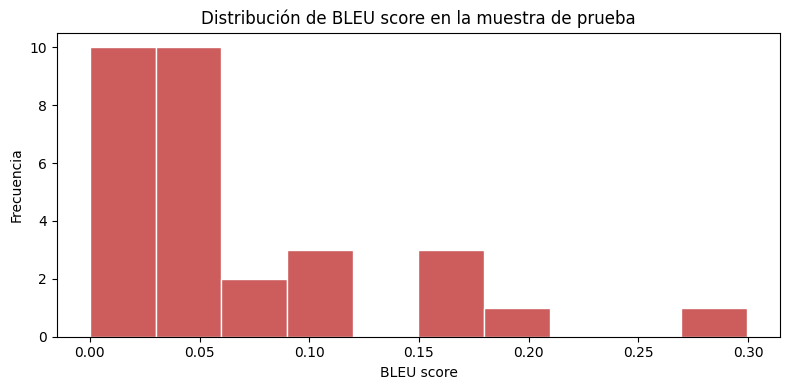

In [20]:
plt.figure(figsize=(8, 4))
plt.hist(bleu_scores, bins=10, color='indianred', edgecolor='white')
plt.title("Distribución de BLEU score en la muestra de prueba")
plt.xlabel("BLEU score")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


## 6. Comparación de configuraciones (Transformer vs arquitecturas tradicionales)

**Diferencias clave a explicar en la presentación:**

| Aspecto | RNN / LSTM | Transformer |
|---|---|---|
| Procesamiento de la secuencia | Secuencial (token a token) | Paralelo (toda la secuencia a la vez) |
| Dependencias de largo alcance | Limitadas (aunque LSTM las mitiga con compuertas) | Capturadas directamente vía autoatención |
| Necesidad de información posicional | Implícita en el orden de procesamiento | Debe agregarse explícitamente (positional embedding) |
| Paralelización en entrenamiento | Difícil (dependencia secuencial) | Alta (todos los tokens se procesan a la vez) |
| Costo computacional en secuencias largas | Crece linealmente | Crece cuadráticamente con el largo (por la atención) |

## 7. Conclusiones

_(completar tras ejecutar y revisar los resultados propios)_

- ¿Qué configuración (`num_heads`, `embed_dim`) obtuvo mejor BLEU y accuracy de validación?
- ¿Qué limitaciones se observaron (largo de secuencia, tamaño del vocabulario, cantidad de épocas)?
- ¿Qué mejoras se podrían implementar a futuro? (ej. *beam search* en vez de greedy decoding, más épocas,
  *warmup* en el learning rate, subword tokenization en vez de word-level).
